# Food Delivery Delay — Exploratory Data Analysis

**Problem.** Given an order (restaurant + customer location, time of day, weather, traffic, kitchen load), predict (1) the **delivery ETA** in minutes and (2) the **probability the order is delivered late** (more than the configured threshold beyond the platform's promised time). These power a customer-facing *best-time-to-order* recommendation.

This notebook explores the data, justifies the modelling choices, and discusses the validation strategy and leakage controls. Full model metrics + diagnostics are in [`docs/model_report.md`](../docs/model_report.md) (generated by `scripts/evaluate.py`).

## 0. Setup

In [1]:
import sys, pathlib
for cand in [pathlib.Path.cwd()/'src', pathlib.Path.cwd().parent/'src']:
    if cand.exists():
        sys.path.insert(0, str(cand)); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from delivery_delay.config import load_config
from delivery_delay.data.loader import load_canonical
from delivery_delay.features.geo import haversine_km
from delivery_delay.features.build import build_xy
cfg = load_config()
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 90

## 1. The data
We use the synthetic generator here (always reproducible). The public-dataset and hybrid sources map into the **same canonical schema** — see [`docs/DATA_DICTIONARY.md`](../docs/DATA_DICTIONARY.md).

In [2]:
df = load_canonical(cfg, source='synthetic', n_orders=20000, seed=42)
print('shape:', df.shape)
df.head()

shape: (20000, 18)


,order_id,timestamp,restaurant_id,restaurant_lat,restaurant_lon,customer_lat,customer_lon,prep_time_minutes,traffic_level,vehicle_type,active_orders,weather_temp_c,weather_precip_mm,weather_wind_kmph,promised_minutes,actual_minutes,delay_minutes,is_delayed
0,ORD-0000000,2025-04-01 23:29:00,R-0049,42.321180,-71.067112,42.344680,-71.077137,29.73,low,scooter,2,13.01,0.00,2.17,36.08,36.02,-0.06,0
1,ORD-0000001,2025-03-26 14:22:00,R-0049,42.321180,-71.067112,42.310000,-71.090506,30.46,medium,bike,3,23.42,0.00,12.15,35.96,40.81,4.85,0
2,ORD-0000002,2025-03-03 11:01:00,R-0022,42.387656,-71.096072,42.390000,-71.120000,22.49,medium,scooter,4,22.97,0.00,7.67,25.87,29.93,4.06,0
3,ORD-0000003,2025-03-03 20:19:00,R-0064,42.360777,-71.077386,42.359617,-71.068738,18.35,high,scooter,2,19.35,0.02,5.51,23.89,22.46,-1.43,0
4,ORD-0000004,2025-05-20 18:26:00,R-0039,42.363585,-71.063542,42.351587,-71.059555,17.78,high,bike,4,23.17,2.73,11.49,22.64,32.08,9.44,1


In [3]:
df[['actual_minutes','promised_minutes','prep_time_minutes','active_orders',
    'weather_precip_mm','weather_wind_kmph']].describe().round(2)

,actual_minutes,promised_minutes,prep_time_minutes,active_orders,weather_precip_mm,weather_wind_kmph
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,33.23,28.23,23.63,5.04,0.40,9.05
std,9.09,5.14,6.15,2.54,1.37,6.36
min,9.84,16.68,8.38,0.00,0.00,0.02
25%,26.74,24.35,19.27,3.00,0.00,4.37
50%,32.15,27.67,22.69,5.00,0.00,7.62
75%,38.52,31.45,27.02,7.00,0.00,12.14
max,110.10,58.53,55.82,18.00,25.78,55.78


In [4]:
print('Missing values per column:')
print(df.isna().sum().to_string())
print('\nNo missing values: the generator emits a complete canonical frame; the public\n'
      'loader fills gaps with neutral defaults and drops rows lacking a target/coords.')

Missing values per column:
order_id             0
timestamp            0
restaurant_id        0
restaurant_lat       0
restaurant_lon       0
customer_lat         0
customer_lon         0
prep_time_minutes    0
traffic_level        0
vehicle_type         0
active_orders        0
weather_temp_c       0
weather_precip_mm    0
weather_wind_kmph    0
promised_minutes     0
actual_minutes       0
delay_minutes        0
is_delayed           0

No missing values: the generator emits a complete canonical frame; the public
loader fills gaps with neutral defaults and drops rows lacking a target/coords.


## 2. Targets
`actual_minutes` is the ETA regression target. `is_delayed` = `(actual - promised) > threshold` is the classification target. The base delay rate (~25–30%) makes this a genuine, reasonably balanced problem rather than a trivial one.

Delay rate: 0.28


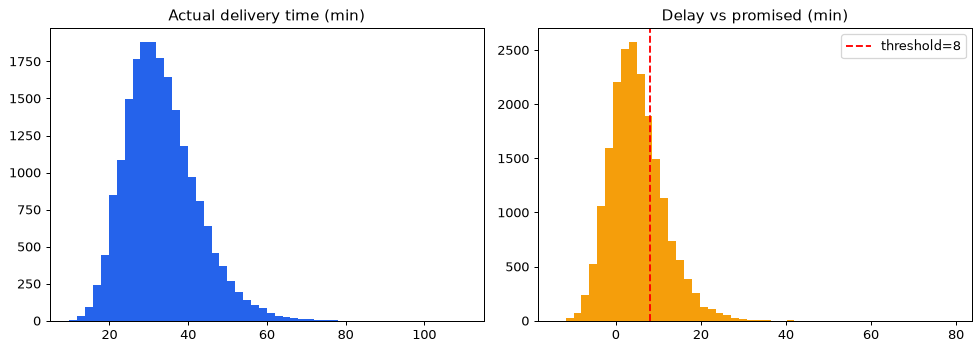

In [5]:
thr = cfg.get('generator.delay_threshold_minutes', 8)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(df['actual_minutes'], bins=50, color='#2563eb'); ax[0].set_title('Actual delivery time (min)')
ax[1].hist(df['delay_minutes'], bins=50, color='#f59e0b'); ax[1].axvline(thr, color='r', ls='--', label=f'threshold={thr}')
ax[1].set_title('Delay vs promised (min)'); ax[1].legend()
plt.tight_layout()
print('Delay rate:', round(df['is_delayed'].mean(), 3))

## 3. Temporal patterns
Lunch and dinner peaks concentrate demand → more kitchen load and slower traffic → higher delay risk. This is exactly the signal the recommendation engine exploits.

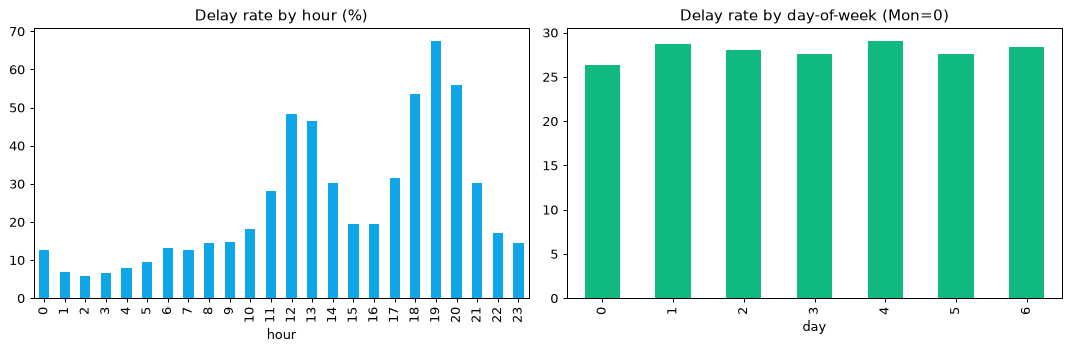

In [6]:
hour = pd.to_datetime(df['timestamp']).dt.hour
dow = pd.to_datetime(df['timestamp']).dt.dayofweek
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.assign(h=hour).groupby('h')['is_delayed'].mean().mul(100).plot(kind='bar', ax=ax[0], color='#0ea5e9')
ax[0].set_title('Delay rate by hour (%)'); ax[0].set_xlabel('hour')
df.assign(d=dow).groupby('d')['is_delayed'].mean().mul(100).plot(kind='bar', ax=ax[1], color='#10b981')
ax[1].set_title('Delay rate by day-of-week (Mon=0)'); ax[1].set_xlabel('day')
plt.tight_layout()

## 4. Distance & weather
Longer routes and rain both push delivery time up.

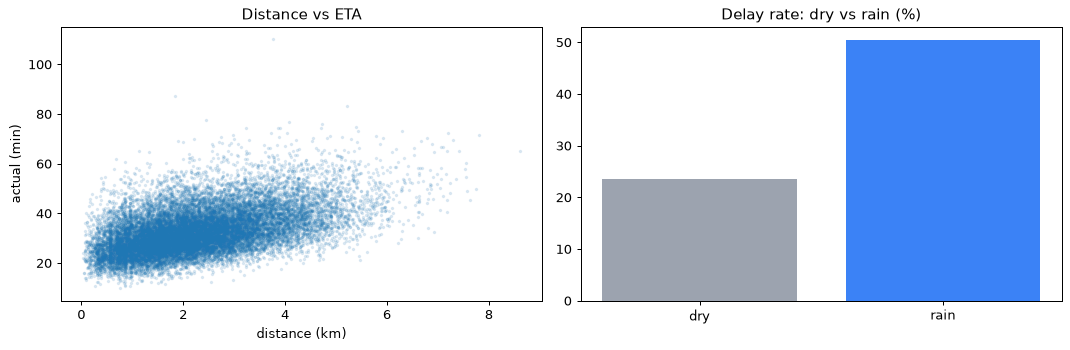

In [7]:
dist = haversine_km(df['restaurant_lat'], df['restaurant_lon'], df['customer_lat'], df['customer_lon'])
rain = df['weather_precip_mm'] > 0
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(dist, df['actual_minutes'], s=3, alpha=0.12); ax[0].set_xlabel('distance (km)')
ax[0].set_ylabel('actual (min)'); ax[0].set_title('Distance vs ETA')
ax[1].bar(['dry', 'rain'], [df.loc[~rain, 'is_delayed'].mean()*100, df.loc[rain, 'is_delayed'].mean()*100],
          color=['#9ca3af', '#3b82f6']); ax[1].set_title('Delay rate: dry vs rain (%)')
plt.tight_layout()

## 5. Traffic & kitchen load

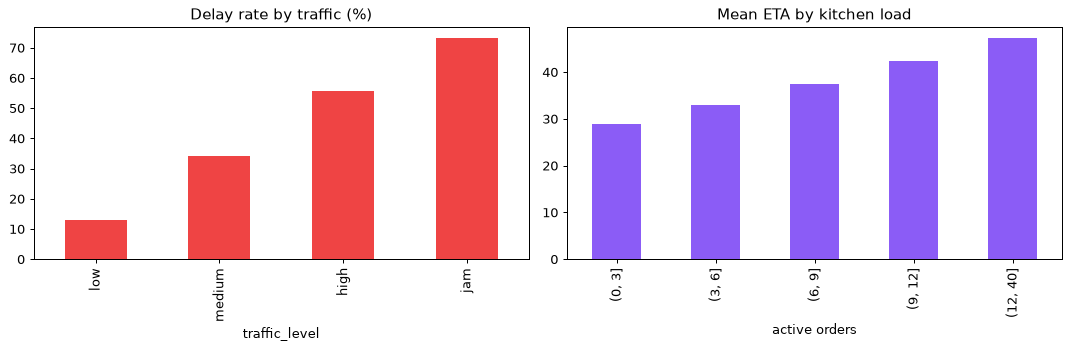

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
order = ['low', 'medium', 'high', 'jam']
df.groupby('traffic_level')['is_delayed'].mean().reindex(order).mul(100).plot(kind='bar', ax=ax[0], color='#ef4444')
ax[0].set_title('Delay rate by traffic (%)')
df.assign(load=pd.cut(df['active_orders'], bins=[0,3,6,9,12,40])).groupby('load', observed=True)['actual_minutes'].mean().plot(kind='bar', ax=ax[1], color='#8b5cf6')
ax[1].set_title('Mean ETA by kitchen load'); ax[1].set_xlabel('active orders')
plt.tight_layout()

## 6. Feature correlations
`promised_minutes` (the platform quote) correlates strongly with `actual_minutes` — it is a legitimate *input known at order time*, not leakage. We **never** use `actual_minutes`, `delay_minutes`, or `is_delayed` as features (see §7).

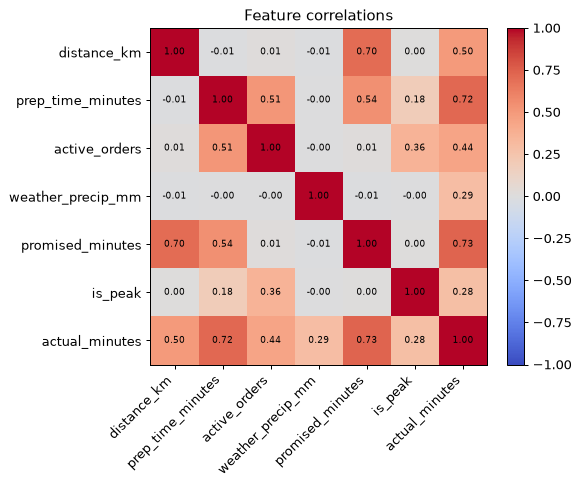

In [9]:
X, y_eta, y_delay = build_xy(df, cfg)
cols = ['distance_km','prep_time_minutes','active_orders','weather_precip_mm','promised_minutes','is_peak']
corr = X[cols].assign(actual_minutes=y_eta.values).corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, fraction=0.046); ax.set_title('Feature correlations'); plt.tight_layout()

## 7. Validation strategy & leakage controls

- **Split.** 80/20 train/test, *stratified on `is_delayed`* so both splits share the delay base rate. Headline numbers are confirmed with **5-fold cross-validation** (see report) — the tiny std rules out a lucky split.
- **Train/serve parity.** The single `build_features` function runs in both training and serving, and categoricals are one-hot encoded against **fixed vocabularies**, so a single prediction request produces exactly the training columns.
- **Leakage.** Features are restricted to information available *at order time*. The outcome columns (`actual_minutes`, `delay_minutes`, `is_delayed`) are targets only. `promised_minutes` is the platform's quote, known up front, so it is a valid feature.

## 8. Why these models
We benchmark against honest baselines (a mean/majority predictor and a linear/logistic model) before reaching for gradient boosting. **XGBoost** is chosen because it captures the non-linear interactions visible above (peak × load, distance × rain) with strong, well-calibrated probabilities — but the baseline table keeps that choice *attributable*, not assumed.

## 9. Quick error analysis
Where does the ETA model err most? A fast model on this sample:

Test MAE: 2.16 min


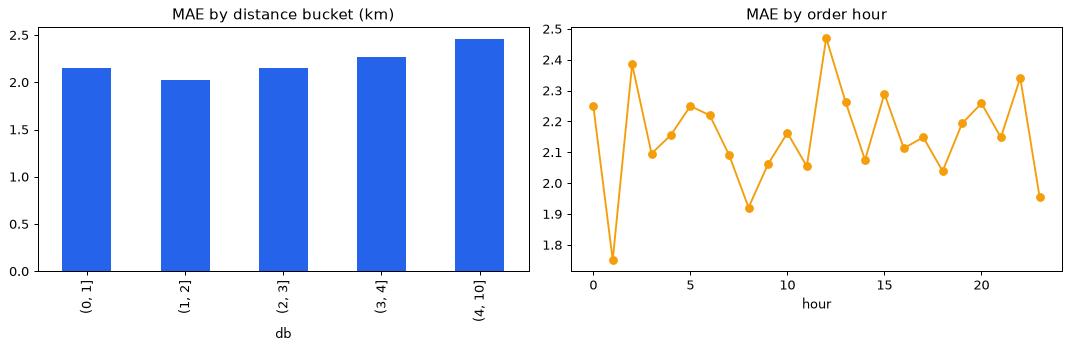

In [10]:
from sklearn.model_selection import train_test_split
from delivery_delay.models.train import _build_eta_model
Xtr, Xte, ytr, yte = train_test_split(X, y_eta, test_size=0.2, random_state=42)
m = _build_eta_model(cfg); m.fit(Xtr, ytr); pred = m.predict(Xte)
err = pd.DataFrame({'abs_err': np.abs(pred - yte.values), 'dist': Xte['distance_km'].values, 'hour': Xte['hour'].values})
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
err.assign(db=pd.cut(err['dist'], bins=[0,1,2,3,4,10])).groupby('db', observed=True)['abs_err'].mean().plot(kind='bar', ax=ax[0], color='#2563eb')
ax[0].set_title('MAE by distance bucket (km)')
err.groupby('hour')['abs_err'].mean().plot(ax=ax[1], marker='o', color='#f59e0b')
ax[1].set_title('MAE by order hour'); ax[1].set_xlabel('hour')
plt.tight_layout()
print('Test MAE: {:.2f} min'.format(np.abs(pred - yte.values).mean()))

## Takeaways
- Delay risk is driven by **peak hours, kitchen load, traffic, distance, and rain** — all available at order time.
- Errors are slightly larger on long routes and at peak hours (more variance), which is where the recommendation's *wait-a-bit* advice is most useful.
- Next steps: richer real-data blending, quantile/prediction intervals for ETA, and online monitoring of feature drift (Prometheus hooks already in the API).